In [2]:
from dask.distributed import Client
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import numpy as np
import xarray as xr
import cmocean as cm
import cartopy.crs as ccrs
import cmocean as cm
import cartopy.feature as cft
import cftime
import IPython.display
import sys, os, warnings
import matplotlib.animation as animation
from cartopy.mpl.geoaxes import GeoAxes  # Import GeoAxes for Cartopy plotting
from mpl_toolkits.axes_grid1 import AxesGrid
import gsw
from xgcm import Grid
import intake
import cf_xarray as cfxr
from access_nri_intake.experiment import use_datastore
from access_nri_intake.source import builders
import os
from xarray import SerializationWarning
import matplotlib.patches as mpatches

In [3]:
client = Client(n_workers=28)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 28
Total threads: 28,Total memory: 251.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38339,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:39869,Total threads: 1
Dashboard: /proxy/37199/status,Memory: 8.97 GiB
Nanny: tcp://127.0.0.1:40343,


<frozen importlib._bootstrap>:241: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject


# First, load datasets we need to analyse

In [4]:
# time period for map
start_time = '2160-01-01'
end_time = '2164-12-31'

In [5]:
catalog = intake.cat.access_nri

In [6]:
#load T

temp_ctrl = catalog['01deg_jra55v13_ryf9091'].search(variable="temp",frequency = '1mon').to_dask()
temp_ctrl = temp_ctrl.temp.sel(time = slice(start_time, end_time))

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:475: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  cat = self.__class__({'esmcat': self.esmcat.dict(), 'df': esmcat_results})
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')


In [7]:
salt_ctrl = catalog['01deg_jra55v13_ryf9091'].search(variable="salt",frequency = '1mon').to_dask()
salt_ctrl = salt_ctrl.salt.sel(time = slice(start_time, end_time))

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:475: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  cat = self.__class__({'esmcat': self.esmcat.dict(), 'df': esmcat_results})
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')


In [8]:
# load WOA data (temperature)
T_woa_01= xr.open_dataset('/g/data/ik11/observations/woa18/woa18_A5B7_t01_04.nc')
T_woa_02= xr.open_dataset('/g/data/ik11/observations/woa18/woa18_A5B7_t02_04.nc')
T_woa_03= xr.open_dataset('/g/data/ik11/observations/woa18/woa18_A5B7_t03_04.nc')
T_woa_04= xr.open_dataset('/g/data/ik11/observations/woa18/woa18_A5B7_t04_04.nc')
T_woa_05= xr.open_dataset('/g/data/ik11/observations/woa18/woa18_A5B7_t05_04.nc')
T_woa_06= xr.open_dataset('/g/data/ik11/observations/woa18/woa18_A5B7_t06_04.nc')
T_woa_07= xr.open_dataset('/g/data/ik11/observations/woa18/woa18_A5B7_t07_04.nc')
T_woa_08= xr.open_dataset('/g/data/ik11/observations/woa18/woa18_A5B7_t08_04.nc')
T_woa_09= xr.open_dataset('/g/data/ik11/observations/woa18/woa18_A5B7_t09_04.nc')
T_woa_010= xr.open_dataset('/g/data/ik11/observations/woa18/woa18_A5B7_t10_04.nc')
T_woa_011= xr.open_dataset('/g/data/ik11/observations/woa18/woa18_A5B7_t11_04.nc')
T_woa_012= xr.open_dataset('/g/data/ik11/observations/woa18/woa18_A5B7_t12_04.nc')

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/argopy/__init__.py:32: DeprecationWarning: The 'argopy.utilities' has moved to 'argopy.utils'. After 0.1.15, importing 'utilities' will raise an error. Please update your script.
  from . import utilities  # noqa: E402  # being deprecated until 0.1.15, then remove
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/wavespectra/core/npstats.py:238: DeprecationWarning: invalid escape sequence '\s'
  """Gaussian frequency spectrum (Bunney et al., 2014).
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/wavespectra/output/ww3.py:25: ResourceWarning: unclosed file <_io.TextIOWrapper name='/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/wavespectra/output/ww3.yml' mode='r' encoding='UTF-8'>
  VAR_ATTRIBUTES = yaml.load(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/w

In [9]:
# load WOA data S
S_woa_01= xr.open_dataset('/g/data/ik11/observations/woa18/woa18_A5B7_s01_04.nc')
S_woa_02= xr.open_dataset('/g/data/ik11/observations/woa18/woa18_A5B7_s02_04.nc')
S_woa_03= xr.open_dataset('/g/data/ik11/observations/woa18/woa18_A5B7_s03_04.nc')
S_woa_04= xr.open_dataset('/g/data/ik11/observations/woa18/woa18_A5B7_s04_04.nc')
S_woa_05= xr.open_dataset('/g/data/ik11/observations/woa18/woa18_A5B7_s05_04.nc')
S_woa_06= xr.open_dataset('/g/data/ik11/observations/woa18/woa18_A5B7_s06_04.nc')
S_woa_07= xr.open_dataset('/g/data/ik11/observations/woa18/woa18_A5B7_s07_04.nc')
S_woa_08= xr.open_dataset('/g/data/ik11/observations/woa18/woa18_A5B7_s08_04.nc')
S_woa_09= xr.open_dataset('/g/data/ik11/observations/woa18/woa18_A5B7_s09_04.nc')
S_woa_010= xr.open_dataset('/g/data/ik11/observations/woa18/woa18_A5B7_s10_04.nc')
S_woa_011= xr.open_dataset('/g/data/ik11/observations/woa18/woa18_A5B7_s11_04.nc')
S_woa_012= xr.open_dataset('/g/data/ik11/observations/woa18/woa18_A5B7_s12_04.nc')

In [9]:
S_woa_01

<xarray.Dataset> Size: 2GB
Dimensions:             (lat: 720, nbounds: 2, lon: 1440, depth: 57, time: 1,
                         climatology_bounds: 2)
Coordinates:
  * lat                 (lat) float32 3kB -89.88 -89.62 -89.38 ... 89.62 89.88
  * lon                 (lon) float32 6kB -179.9 -179.6 -179.4 ... 179.6 179.9
  * depth               (depth) float32 228B 0.0 5.0 10.0 ... 1.45e+03 1.5e+03
  * time                (time) datetime64[ns] 8B 2011-01-01T17:59:59.500000
  * climatology_bounds  (climatology_bounds) datetime64[ns] 16B 2005-01-01 20...
Dimensions without coordinates: nbounds
Data variables:
    crs                 int32 4B ...
    lat_bnds            (lat, nbounds) float32 6kB ...
    lon_bnds            (lon, nbounds) float32 12kB ...
    depth_bnds          (depth, nbounds) float32 456B ...
    s_an                (time, depth, lat, lon) float32 236MB ...
    s_mn                (time, depth, lat, lon) float32 236MB ...
    s_dd                (time, depth, lat, lon) float64 473MB ...
    s_sd                (time, depth, lat, lon) float32 236MB ...
    s_se                (time, depth, lat, lon) float32 236MB ...
    s_oa                (time, depth, lat, lon) float32 236MB ...
    s_ma                (time, depth, lat, lon) float32 236MB ...
    s_gp                (time, depth, lat, lon) float64 473MB ...
Attributes: (12/49)
    Conventions:                     CF-1.6, ACDD-1.3
    title:                           World Ocean Atlas 2018 : sea_water_salin...
    summary:                         Climatological mean salinity for the glo...
    references:                      Zweng, M. M, J. R. Reagan, D. Seidov, T....
    institution:                     National Centers for Environmental Infor...
    comment:                         global climatology as part of the World ...
    ...                              ...
    publisher_email:                 NCEI.info@noaa.gov
    nodc_template_version:           NODC_NetCDF_Grid_Template_v2.0
    license:                         These data are openly available to the p...
    metadata_link:                   https://www.nodc.noaa.gov/OC5/woa18/
    date_created:                    2019-07-29 
    date_modified:                   2019-07-29

# CDW in WOA18 data (2005-2017) 

In [10]:
# time
start_time = '2005-01-01'
end_time = '2017-12-31'

In [11]:
T_woa_1 = T_woa_01.t_an
T_woa_2 = T_woa_02.t_an
T_woa_3 = T_woa_03.t_an
T_woa_4 = T_woa_04.t_an
T_woa_5 = T_woa_05.t_an
T_woa_6 = T_woa_06.t_an
T_woa_7 = T_woa_07.t_an
T_woa_8 = T_woa_08.t_an
T_woa_9 = T_woa_09.t_an
T_woa_10 = T_woa_010.t_an
T_woa_11 = T_woa_011.t_an
T_woa_12 = T_woa_012.t_an

In [12]:
T_woa = xr.concat([T_woa_1,T_woa_2,T_woa_3,T_woa_4,T_woa_5,T_woa_6,T_woa_7,T_woa_8,T_woa_9,T_woa_10,T_woa_11,T_woa_12], dim = 'time')

In [13]:
S_woa_1 = S_woa_01.s_an
S_woa_2 = S_woa_02.s_an
S_woa_3 = S_woa_03.s_an
S_woa_4 = S_woa_04.s_an
S_woa_5 = S_woa_05.s_an
S_woa_6 = S_woa_06.s_an
S_woa_7 = S_woa_07.s_an
S_woa_8 = S_woa_08.s_an
S_woa_9 = S_woa_09.s_an
S_woa_10 = S_woa_010.s_an
S_woa_11 = S_woa_011.s_an
S_woa_12 = S_woa_012.s_an
S_woa = xr.concat([S_woa_1,S_woa_2,S_woa_3,S_woa_4,S_woa_5,S_woa_6,S_woa_7,S_woa_8,S_woa_9,S_woa_10,S_woa_11,S_woa_12], dim = 'time')

In [14]:
# calculate the temporal mean
T_woa_mean = T_woa.sel(lat = slice(-90,-50)).mean('time').load()

In [15]:
S_woa_mean = S_woa.sel(lat = slice(-90,-50)).mean('time').load()

In [16]:
# convert insitu temperature to conservative temperature
T_woa_mean = gsw.CT_from_t(S_woa_mean, T_woa_mean, 0)

In [17]:
temp_ctrl_mean = temp_ctrl.sel(yt_ocean = slice(-90,-50)).mean('time').load()

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 73.91 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [18]:
salt_ctrl_mean = salt_ctrl.sel(yt_ocean = slice(-90,-50)).mean('time').load()

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 73.91 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [19]:
# practical salinity to absolute salinity
salt_ctrl_mean = gsw.conversions.SA_from_SP(salt_ctrl_mean,salt_ctrl_mean.st_ocean,salt_ctrl_mean.xt_ocean,salt_ctrl_mean.yt_ocean)
# conservative temp and absolute salinity to sigma1
rho_ctrl_mean = gsw.density.sigma1(salt_ctrl_mean, temp_ctrl_mean-273.15)

In [20]:
# practical salinity to absolute salinity
S_woa_mean = gsw.conversions.SA_from_SP(S_woa_mean,S_woa_mean.depth,S_woa_mean.lon,S_woa_mean.lat)
# conservative temp and absolute salinity to sigma1
rho_woa_mean = gsw.density.sigma1(S_woa_mean, T_woa_mean)

In [21]:
temp_ctrl_mean = temp_ctrl_mean.mean('xt_ocean').load()
salt_ctrl_mean = salt_ctrl_mean.mean('xt_ocean').load()
rho_ctrl_mean = rho_ctrl_mean.mean('xt_ocean').load()

In [22]:
T_woa_mean = T_woa_mean.mean('lon').load()
S_woa_mean = S_woa_mean.mean('lon').load()
rho_woa_mean = rho_woa_mean.mean('lon').load()

In [23]:
rho_woa_mean

<xarray.DataArray 's_an' (depth: 57, lat: 160)> Size: 73kB
array([[        nan,         nan,         nan, ..., 31.3052023 ,
        31.286025  , 31.26760923],
       [        nan,         nan,         nan, ..., 31.30680196,
        31.28765967, 31.26922851],
       [        nan,         nan,         nan, ..., 31.31861433,
        31.29984346, 31.28198441],
       ...,
       [        nan,         nan,         nan, ..., 32.27856608,
        32.2698637 , 32.26026009],
       [        nan,         nan,         nan, ..., 32.29302839,
        32.28519595, 32.27646823],
       [        nan,         nan,         nan, ..., 32.3072135 ,
        32.29987627, 32.29160063]])
Coordinates:
  * lat      (lat) float32 640B -89.88 -89.62 -89.38 ... -50.62 -50.38 -50.12
  * depth    (depth) float32 228B 0.0 5.0 10.0 15.0 ... 1.4e+03 1.45e+03 1.5e+03

In [24]:
land_2 = xr.where(np.isnan(T_woa_mean[:,:].rename('land')), 1, np.nan)

land_1 = xr.where(np.isnan(temp_ctrl_mean[:,:].rename('land')), 1, np.nan)

# Now we plot these data.

In [25]:
background_1 = xr.DataArray(
    data=np.ones_like(T_woa_mean),
    coords=T_woa_mean.coords,
    dims=T_woa_mean.dims,
    name='ones_array'
)

background_2 = xr.DataArray(
    data=np.ones_like(temp_ctrl_mean),
    coords=temp_ctrl_mean.coords,
    dims=temp_ctrl_mean.dims,
    name='ones_array'
)

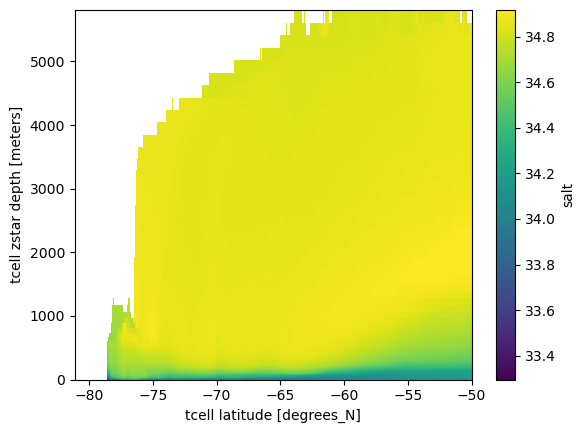

In [27]:
salt_ctrl_mean.plot()

<>:169: DeprecationWarning: invalid escape sequence '\c'
<>:169: DeprecationWarning: invalid escape sequence '\c'
<unknown>:169: DeprecationWarning: invalid escape sequence '\c'
/jobfs/155918972.gadi-pbs/ipykernel_2685337/3555971072.py:169: DeprecationWarning: invalid escape sequence '\c'
  cb.ax.set_ylabel('temperature ($^{\circ}$C)', fontsize = 12)


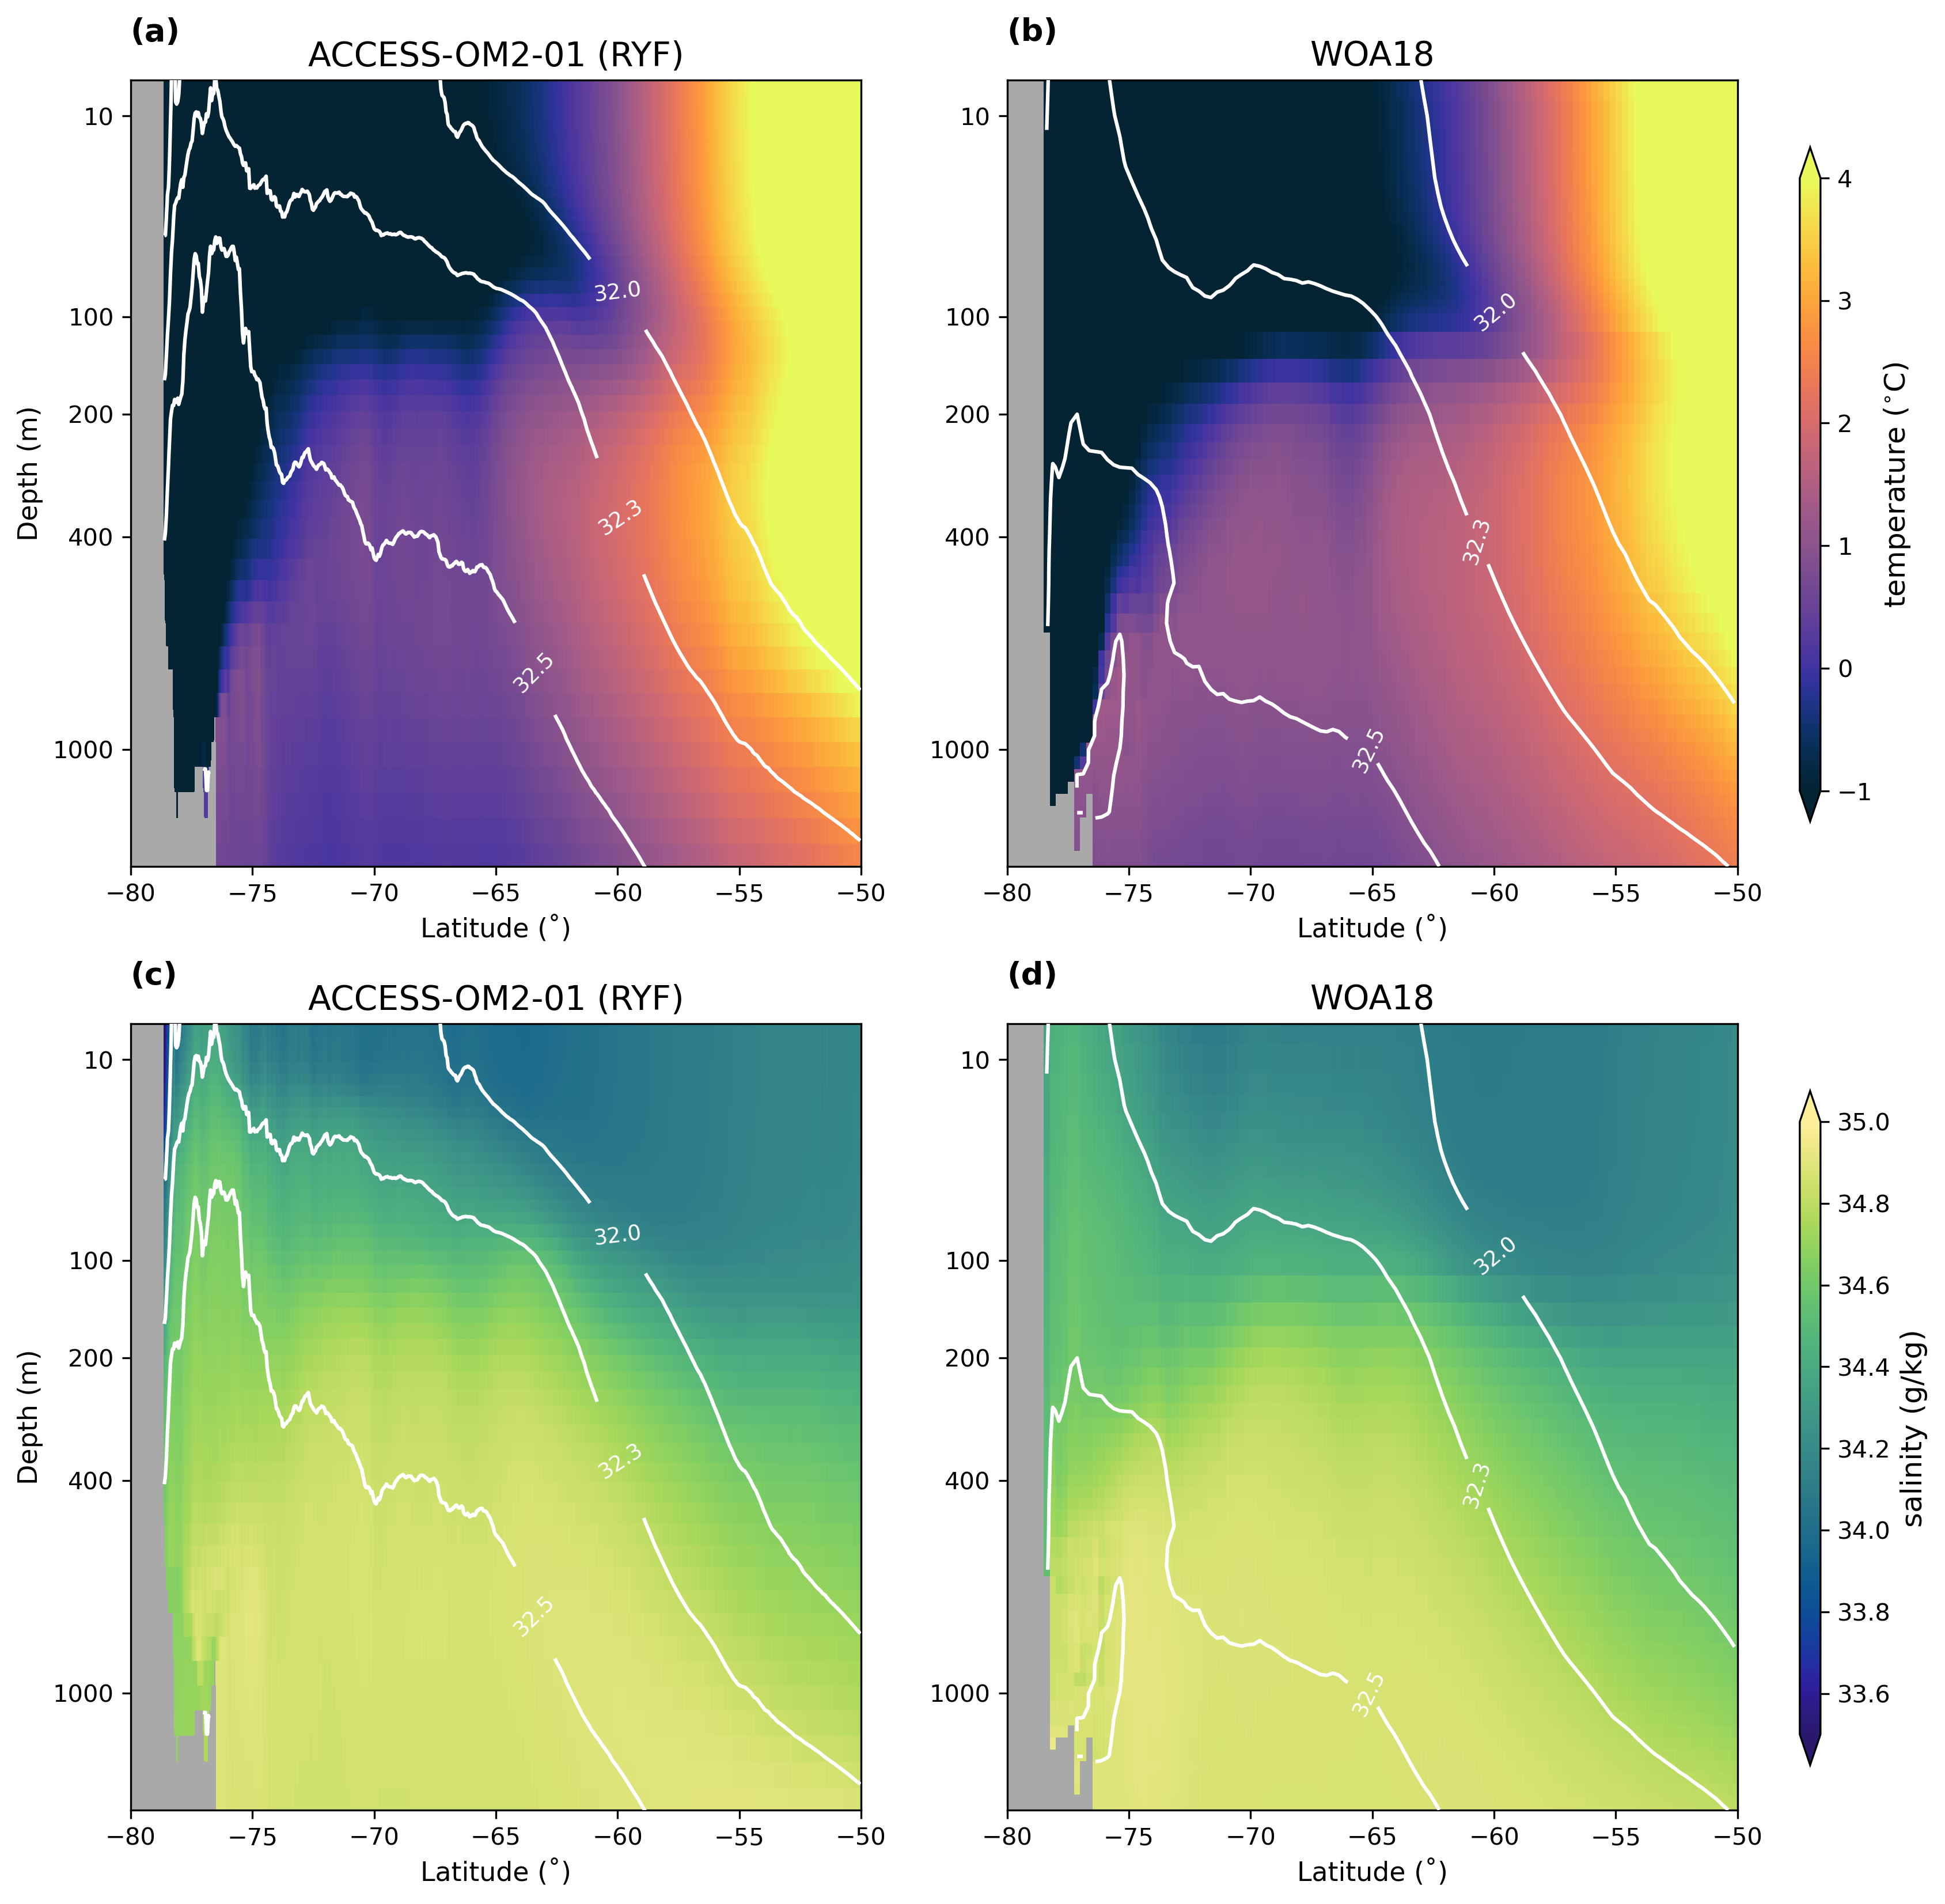

In [32]:
# Initial state of the CDW
fig = plt.figure(figsize=(12,13),dpi = 300)
levs_dens = [32.0,32.3,32.5]
manual_positions1 = [
    (-60, 100), 
    (-60, 400),
    (-65,1000)
]
# transect 
ax = plt.subplot(2,2,2)
background_1[:,:].plot.contourf(ax=ax, colors='darkgrey', zorder=0,
                        add_colorbar=False)
p1 = (T_woa_mean.sel(depth = slice(1.,8000))).plot(vmin=-1,vmax=4, cmap = cm.cm.thermal,add_colorbar = False)
c2 = plt.contour(rho_woa_mean.lat.values,rho_woa_mean[1:,:].depth.values,rho_woa_mean.sel(depth = slice(1.,8000)),levels=levs_dens,colors='white',linestyles='-',linewidths=1.5,zorder=5)
#c2 = plt.contour(rho_woa_mean.lat.values,rho_woa_mean[1:,:].depth.values,rho_woa_mean.sel(depth = slice(1.,8000)),levels=levs_dens,colors='white',linestyles='--',linewidths=1.5,zorder=5)
plt.clabel(c2,fontsize=9,inline=True,fmt='%1.1f',levels=levs_dens,manual = manual_positions1)
#plt.plot(mld_summer.yt_ocean.values,mld_summer.values)
land_2[:,:].plot.contourf(ax=ax, colors='darkgrey', zorder=0,
                        add_colorbar=False)
#land_2.fillna(0).plot.contour(ax=ax, colors='k', levels=[0, 1],
#                       add_colorbar=False,linewidths = 1.6)  
plt.ylim(5,1500)
plt.yticks([10,200,400,1000], [10,200,400,1000])  
def forward(x):
    return x**(1/3)
def inverse(x):
    return x**3
plt.gca().set_yscale('function', functions=(forward, inverse))
plt.gca().invert_yaxis()
plt.xlabel('Latitude (˚)', fontsize = 11)
plt.ylabel(' ', fontsize = 11)
plt.xlim(-80,-50)
plt.yticks([10,100,200,400,1000], [10,100,200,400,1000])  
#plt.plot([-10,20], [400,400], linestyle='--', color='k')
#plt.plot(bound_up_ctrl_mean[200:300].yt_ocean.values, bound_up_ctrl_mean[200:300].values, c = 'k',linewidth=2)
#plt.plot([10,10],[180,400], c = 'k',linewidth=2)
#plt.plot([10,10],[180,400], c = 'k',linewidth=2)
#plt.plot([0,10],[400,400], c = 'k',linewidth=2)
#plt.text(-62,450,'CDW',fontsize = 14,color = 'k')
#plt.text(7,650,'LCDW',fontsize = 12,color = 'k')
#plt.plot(lower_bound_th_mean[200:300].yt_ocean.values, lower_bound_th_mean[200:300].values, c = 'k',linewidth=2)
#plt.plot([10,10],[400,lower_bound_th_mean[300].values], c = 'k',linewidth=2)
#plt.plot([0,0],[400,lower_bound_th_mean[201].values], c = 'k',linewidth=2)
#plt.ylabel(' ', fontsize = 12)
ax.set_title('WOA18', fontsize = 14)
ax.text(0.0, 1.08, '(b)', transform=ax.transAxes, fontweight='bold', fontsize=13,verticalalignment='top',horizontalalignment='left')

# transect 
ax = plt.subplot(2,2,1)
background_2[:,:].plot.contourf(ax=ax, colors='darkgrey', zorder=0,
                        add_colorbar=False)
p1 = (temp_ctrl_mean.sel(st_ocean = slice(1.,8000))-273.15).plot(vmin=-1,vmax=4, cmap = cm.cm.thermal,add_colorbar = False)
c2 = plt.contour(rho_ctrl_mean.yt_ocean.values,rho_ctrl_mean[1:75,:].st_ocean.values,rho_ctrl_mean.sel(st_ocean = slice(1.,8000)),levels=levs_dens,colors='white',linestyles='-',linewidths=1.5,zorder=5)
#c2 = plt.contour(rho_ctrl_mean.yt_ocean.values,rho_ctrl_mean[1:75,:].st_ocean.values,rho_ctrl_mean.sel(st_ocean = slice(1.,8000)),levels=levs_dens,colors='',linestyles='--',linewidths=1.5,zorder=5)
plt.clabel(c2,fontsize=9,inline=True,fmt='%1.1f',levels=levs_dens,manual = manual_positions1)
#ax1.text(0.367,2.55,'Heat budget',fontsize = 11,color = 'k',fontweight='bold')
plt.ylim(5,1500)
plt.yticks([10,100,200,400,1000], [10,100,200,400,1000])  
land_1[:,:].plot.contourf(ax=ax, colors='darkgrey', zorder=2,
                        add_colorbar=False)
#plt.plot(mld_winter.yt_ocean.values,mld_winter.values)
def forward(x):
    return x**(1/3)
def inverse(x):
    return x**3
plt.gca().set_yscale('function', functions=(forward, inverse))
plt.gca().invert_yaxis()
plt.xlabel('Latitude (˚)', fontsize = 11)

plt.ylabel('Depth (m)', fontsize = 11)
plt.xlim(-80,-50)
plt.yticks([10,100,200,400,1000], [10,100,200,400,1000])  
#plt.plot([-10,20], [400,400], linestyle='--', color='k')
#plt.plot(bound_up_ctrl_mean[200:300].yt_ocean.values, bound_up_ctrl_mean[200:300].values, c = 'k',linewidth=2)
#plt.plot([10,10],[180,400], c = 'k',linewidth=2)
#plt.plot([10,10],[180,400], c = 'k',linewidth=2)
#plt.plot([0,10],[400,400], c = 'k',linewidth=2)
#plt.text(-62,450,'CDW',fontsize = 14,color = 'k')
#plt.text(7,650,'LCDW',fontsize = 12,color = 'k')
#plt.plot(lower_bound_th_mean[200:300].yt_ocean.values, lower_bound_th_mean[200:300].values, c = 'k',linewidth=2)
#plt.plot([10,10],[400,lower_bound_th_mean[300].values], c = 'k',linewidth=2)
#plt.plot([0,0],[400,lower_bound_th_mean[201].values], c = 'k',linewidth=2)
#plt.ylabel(' ', fontsize = 12)
ax.set_title('ACCESS-OM2-01 (RYF)', fontsize = 14)
ax.text(0.0, 1.08, '(a)', transform=ax.transAxes, fontweight='bold', fontsize=13,verticalalignment='top',horizontalalignment='left')


# transect 
ax = plt.subplot(2,2,3)
background_2[:,:].plot.contourf(ax=ax, colors='darkgrey', zorder=0,
                        add_colorbar=False)
p3 = (salt_ctrl_mean.sel(st_ocean = slice(1.,8000))).plot(vmin=33.5,vmax=35, cmap = cm.cm.haline,add_colorbar = False)
c2 = plt.contour(rho_ctrl_mean.yt_ocean.values,rho_ctrl_mean[1:75,:].st_ocean.values,rho_ctrl_mean.sel(st_ocean = slice(1.,8000)),levels=levs_dens,colors='white',linestyles='-',linewidths=1.5,zorder=5)
#c2 = plt.contour(rho_ctrl_mean.yt_ocean.values,rho_ctrl_mean[1:75,:].st_ocean.values,rho_ctrl_mean.sel(st_ocean = slice(1.,8000)),levels=levs_dens,colors='',linestyles='--',linewidths=1.5,zorder=5)
plt.clabel(c2,fontsize=9,inline=True,fmt='%1.1f',levels=levs_dens,manual = manual_positions1)
#ax1.text(0.367,2.55,'Heat budget',fontsize = 11,color = 'k',fontweight='bold')
plt.ylim(5,1500)
plt.yticks([10,100,200,400,1000], [10,100,200,400,1000])  
land_1[:,:].plot.contourf(ax=ax, colors='darkgrey', zorder=2,
                        add_colorbar=False)
#plt.plot(mld_winter.yt_ocean.values,mld_winter.values)
def forward(x):
    return x**(1/3)
def inverse(x):
    return x**3
plt.gca().set_yscale('function', functions=(forward, inverse))
plt.gca().invert_yaxis()
plt.xlabel('Latitude (˚)', fontsize = 11)

plt.ylabel('Depth (m)', fontsize = 11)
plt.xlim(-80,-50)
plt.yticks([10,100,200,400,1000], [10,100,200,400,1000])  
#plt.plot([-10,20], [400,400], linestyle='--', color='k')
#plt.plot(bound_up_ctrl_mean[200:300].yt_ocean.values, bound_up_ctrl_mean[200:300].values, c = 'k',linewidth=2)
#plt.plot([10,10],[180,400], c = 'k',linewidth=2)
#plt.plot([10,10],[180,400], c = 'k',linewidth=2)
#plt.plot([0,10],[400,400], c = 'k',linewidth=2)
#plt.text(-62,450,'CDW',fontsize = 14,color = 'k')
#plt.text(7,650,'LCDW',fontsize = 12,color = 'k')
#plt.plot(lower_bound_th_mean[200:300].yt_ocean.values, lower_bound_th_mean[200:300].values, c = 'k',linewidth=2)
#plt.plot([10,10],[400,lower_bound_th_mean[300].values], c = 'k',linewidth=2)
#plt.plot([0,0],[400,lower_bound_th_mean[201].values], c = 'k',linewidth=2)
#plt.ylabel(' ', fontsize = 12)
ax.set_title('ACCESS-OM2-01 (RYF)', fontsize = 14)
ax.text(0.0, 1.08, '(c)', transform=ax.transAxes, fontweight='bold', fontsize=13,verticalalignment='top',horizontalalignment='left')


ax = plt.subplot(2,2,4)
background_1[:,:].plot.contourf(ax=ax, colors='darkgrey', zorder=0,
                        add_colorbar=False)
p3 = (S_woa_mean.sel(depth = slice(1.,8000))).plot(vmin=33.5,vmax=35, cmap = cm.cm.haline,add_colorbar = False)
c2 = plt.contour(rho_woa_mean.lat.values,rho_woa_mean[1:,:].depth.values,rho_woa_mean.sel(depth = slice(1.,8000)),levels=levs_dens,colors='white',linestyles='-',linewidths=1.5,zorder=5)
#c2 = plt.contour(rho_woa_mean.lat.values,rho_woa_mean[1:,:].depth.values,rho_woa_mean.sel(depth = slice(1.,8000)),levels=levs_dens,colors='white',linestyles='--',linewidths=1.5,zorder=5)
plt.clabel(c2,fontsize=9,inline=True,fmt='%1.1f',levels=levs_dens,manual = manual_positions1)
#plt.plot(mld_summer.yt_ocean.values,mld_summer.values)
land_2[:,:].plot.contourf(ax=ax, colors='darkgrey', zorder=0,
                        add_colorbar=False)
#land_2.fillna(0).plot.contour(ax=ax, colors='k', levels=[0, 1],
#                       add_colorbar=False,linewidths = 1.6)  
plt.ylim(5,1500)
plt.yticks([10,200,400,1000], [10,200,400,1000])  
def forward(x):
    return x**(1/3)
def inverse(x):
    return x**3
plt.gca().set_yscale('function', functions=(forward, inverse))
plt.gca().invert_yaxis()
plt.xlabel('Latitude (˚)', fontsize = 11)
plt.ylabel(' ', fontsize = 11)
plt.xlim(-80,-50)
plt.yticks([10,100,200,400,1000], [10,100,200,400,1000])  
#plt.plot([-10,20], [400,400], linestyle='--', color='k')
#plt.plot(bound_up_ctrl_mean[200:300].yt_ocean.values, bound_up_ctrl_mean[200:300].values, c = 'k',linewidth=2)
#plt.plot([10,10],[180,400], c = 'k',linewidth=2)
#plt.plot([10,10],[180,400], c = 'k',linewidth=2)
#plt.plot([0,10],[400,400], c = 'k',linewidth=2)
#plt.text(-62,450,'CDW',fontsize = 14,color = 'k')
#plt.text(7,650,'LCDW',fontsize = 12,color = 'k')
#plt.plot(lower_bound_th_mean[200:300].yt_ocean.values, lower_bound_th_mean[200:300].values, c = 'k',linewidth=2)
#plt.plot([10,10],[400,lower_bound_th_mean[300].values], c = 'k',linewidth=2)
#plt.plot([0,0],[400,lower_bound_th_mean[201].values], c = 'k',linewidth=2)
#plt.ylabel(' ', fontsize = 12)
ax.set_title('WOA18', fontsize = 14)
ax.text(0.0, 1.08, '(d)', transform=ax.transAxes, fontweight='bold', fontsize=13,verticalalignment='top',horizontalalignment='left')


ax_cb1 = plt.axes([0.93, 0.55, 0.01, 0.3])
cb = plt.colorbar(p1, cax=ax_cb1,  orientation='vertical',extend='both')
cb.ax.set_ylabel('temperature ($^{\circ}$C)', fontsize = 12)
cb.ax.yaxis.set_label_position('right')
cb.ax.yaxis.set_ticks_position('right')

ax_cb1 = plt.axes([0.93, 0.13, 0.01, 0.3])
cb = plt.colorbar(p3, cax=ax_cb1,  orientation='vertical',extend='both')
cb.ax.set_ylabel('salinity (g/kg)', fontsize = 12)
cb.ax.yaxis.set_label_position('right')
cb.ax.yaxis.set_ticks_position('right')

In [26]:
T_woa_mean.depth

<xarray.DataArray 'depth' (depth: 57)> Size: 228B
array([   0.,    5.,   10.,   15.,   20.,   25.,   30.,   35.,   40.,   45.,
         50.,   55.,   60.,   65.,   70.,   75.,   80.,   85.,   90.,   95.,
        100.,  125.,  150.,  175.,  200.,  225.,  250.,  275.,  300.,  325.,
        350.,  375.,  400.,  425.,  450.,  475.,  500.,  550.,  600.,  650.,
        700.,  750.,  800.,  850.,  900.,  950., 1000., 1050., 1100., 1150.,
       1200., 1250., 1300., 1350., 1400., 1450., 1500.], dtype=float32)
Coordinates:
  * depth    (depth) float32 228B 0.0 5.0 10.0 15.0 ... 1.4e+03 1.45e+03 1.5e+03
Attributes:
    standard_name:  depth
    bounds:         depth_bnds
    positive:       down
    units:          meters
    axis:           Z